In [21]:
!pip install pandas_datareader

In [22]:
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'
import pandas_datareader.data as web
import pandas as pd

# 拉取Fama-French 100个行业组合的月度收益率
ff_portfolios = web.DataReader(
    '10_Industry_Portfolios',
    'famafrench',
    start='2018-01-01'
)[0]  # [0]是月度收益率表

print(ff_portfolios.tail())
print("维度：", ff_portfolios.shape)

         NoDur  Durbl  Manuf  Enrgy  HiTec  Telcm  Shops   Hlth  Utils  Other
Date                                                                         
2025-10  -3.35   2.56   2.76  -0.81   5.59  -5.85   1.74   4.28   0.44  -2.78
2025-11   5.26  -3.71  -0.29   2.37  -2.52  -1.45   0.28  10.86   2.90   1.74
2025-12  -0.86   4.39   1.47  -0.80  -0.63   3.71  -1.32  -1.53  -4.27   1.97
2026-01   7.00  -2.44  10.65  13.80  -0.84   3.40   5.00   0.52   2.86  -0.81
2026-02   7.11  -4.64   7.28   8.69  -4.90   4.04  -1.78   4.63   9.90  -0.89
维度： (98, 10)


<ipython-input-22-f69d2d25394c>:7: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_portfolios = web.DataReader(
<ipython-input-22-f69d2d25394c>:7: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_portfolios = web.DataReader(
<ipython-input-22-f69d2d25394c>:7: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_portfolios = web.DataReader(
<ipython-input-22-f69d2d25394c>:7: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'objec

In [23]:
# Step 2: 动量策略回测
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'
# 收益率数据除以100（原始数据是百分比形式）
ret = ff_portfolios / 100

# 计算过去12个月的累计收益（动量信号）
momentum = ret.rolling(12).sum().shift(1)  # shift(1)避免用到当月数据

# 每个月：买入动量最强的行业，做空动量最弱的行业
long_ret = []
short_ret = []
dates = []

for date in ret.index[12:]:  # 从第13个月开始，前12个月用来计算信号
    signal = momentum.loc[date]
    
    best = signal.idxmax()   # 动量最强
    worst = signal.idxmin()  # 动量最弱
    
    long_ret.append(ret.loc[date, best])
    short_ret.append(ret.loc[date, worst])
    dates.append(date)

# 整理成DataFrame
results = pd.DataFrame({
    'long': long_ret,
    'short': short_ret,
}, index=dates)

# 多空组合收益 = 买入最强 - 买入最弱
results['long_short'] = results['long'] - results['short']

print(results.tail(10))
print("\n平均月度收益：")
print(results.mean().round(4))

           long   short  long_short
2025-05  0.1886  0.0178      0.1708
2025-06 -0.0584  0.0513     -0.1097
2025-07 -0.0115  0.0353     -0.0468
2025-08  0.0804  0.0441      0.0363
2025-09  0.2511  0.0203      0.2308
2025-10  0.0256 -0.0335      0.0591
2025-11 -0.0371  0.0526     -0.0897
2025-12  0.0439  0.0371      0.0068
2026-01 -0.0084  0.0700     -0.0784
2026-02 -0.0490 -0.0178     -0.0312

平均月度收益：
long          0.0318
short         0.0059
long_short    0.0259
dtype: float64


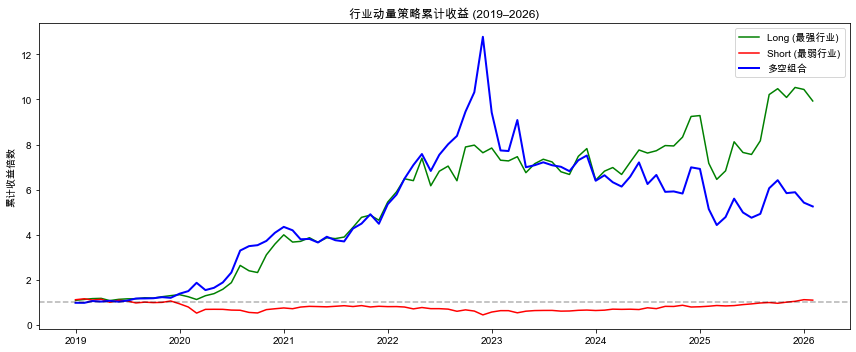

=== 策略表现指标 ===

long:
  年化收益率: 38.2%
  年化波动率: 35.0%
  夏普比率:   1.09
  最大回撤:   -30.5%

short:
  年化收益率: 7.1%
  年化波动率: 33.9%
  夏普比率:   0.21
  最大回撤:   -62.1%

long_short:
  年化收益率: 31.1%
  年化波动率: 39.9%
  夏普比率:   0.78
  最大回撤:   -65.4%


In [24]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'
# 累计收益曲线
cumulative = (1 + results).cumprod()
cumulative.index = cumulative.index.to_timestamp()  # 加这一行

plt.figure(figsize=(12, 5))
plt.plot(cumulative['long'], label='Long (最强行业)', color='green')
plt.plot(cumulative['short'], label='Short (最弱行业)', color='red')
plt.plot(cumulative['long_short'], label='多空组合', color='blue', linewidth=2)
plt.axhline(y=1, color='black', linestyle='--', alpha=0.3)
plt.title('行业动量策略累计收益 (2019–2026)')
plt.ylabel('累计收益倍数')
plt.legend()
plt.tight_layout()
plt.show()

# 计算专业指标
def sharpe(returns, freq=12):
    return (returns.mean() / returns.std()) * np.sqrt(freq)

def max_drawdown(returns):
    cum = (1 + returns).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd.min()

print("=== 策略表现指标 ===")
for col in ['long', 'short', 'long_short']:
    print(f"\n{col}:")
    print(f"  年化收益率: {results[col].mean()*12:.1%}")
    print(f"  年化波动率: {results[col].std()*np.sqrt(12):.1%}")
    print(f"  夏普比率:   {sharpe(results[col]):.2f}")
    print(f"  最大回撤:   {max_drawdown(results[col]):.1%}")

=== 原策略 vs 优化策略 ===

原策略:
  年化收益率: 31.1%
  夏普比率:   0.78
  最大回撤:   -65.4%

优化策略:
  年化收益率: 14.8%
  夏普比率:   0.85
  最大回撤:   -29.0%


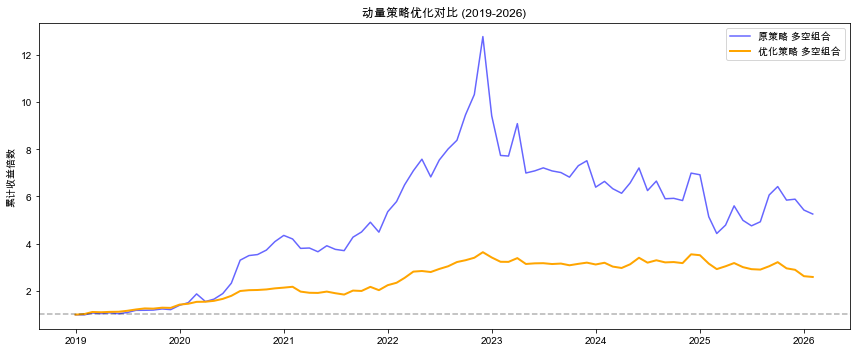

In [25]:
# Step 4: 加入风险控制
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'
# 计算每个行业的历史波动率（过去12个月）
vol = ret.rolling(12).std()

# 波动率加权：波动越大，仓位越小
# 每个月找出最强/最弱行业，用波动率调整实际仓位大小
long_ret_adj = []
short_ret_adj = []
dates_adj = []

# 目标年化波动率（控制整体风险）
target_vol = 0.15 / np.sqrt(12)  # 15%年化波动率

for date in ret.index[12:]:
    signal = momentum.loc[date]
    vol_today = vol.loc[date]
    
    best = signal.idxmax()
    worst = signal.idxmin()
    
    # 根据波动率计算仓位比例
    long_position = min(target_vol / vol_today[best], 1.5)   # 最大1.5倍杠杆
    short_position = min(target_vol / vol_today[worst], 1.5)
    
    long_ret_adj.append(ret.loc[date, best] * long_position)
    short_ret_adj.append(ret.loc[date, worst] * short_position)
    dates_adj.append(date)

results_adj = pd.DataFrame({
    'long': long_ret_adj,
    'short': short_ret_adj,
}, index=dates_adj)

results_adj['long_short'] = results_adj['long'] - results_adj['short']

# 对比原策略和优化策略
print("=== 原策略 vs 优化策略 ===")
for col in ['long_short']:
    print(f"\n原策略:")
    print(f"  年化收益率: {results[col].mean()*12:.1%}")
    print(f"  夏普比率:   {sharpe(results[col]):.2f}")
    print(f"  最大回撤:   {max_drawdown(results[col]):.1%}")
    print(f"\n优化策略:")
    print(f"  年化收益率: {results_adj[col].mean()*12:.1%}")
    print(f"  夏普比率:   {sharpe(results_adj[col]):.2f}")
    print(f"  最大回撤:   {max_drawdown(results_adj[col]):.1%}")

# 画对比图
cumulative_adj = (1 + results_adj).cumprod()
cumulative_adj.index = cumulative_adj.index.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(cumulative['long_short'], label='原策略 多空组合', color='blue', alpha=0.6)
plt.plot(cumulative_adj['long_short'], label='优化策略 多空组合', color='orange', linewidth=2)
plt.axhline(y=1, color='black', linestyle='--', alpha=0.3)
plt.title('动量策略优化对比 (2019-2026)')
plt.ylabel('累计收益倍数')
plt.legend()
plt.tight_layout()
plt.show()